## Model Training - Bag Of Words

- We will use preprocessing or feature extraction method of Bag of words.
- In this method we will hot encode, each and every word from the vocabulary of the corpus.
- The the corpus will be preprocessed to remove the stopwords, this will help remove the noise from the data.
- We will use different ML Models to analyse the performance of each model

#### ML Models:
- Logistic Regression
- Random Forest
- XG Boost
- MLP (will implement it with keras library and Scratch code)

In [21]:
import pandas as pd
import numpy as np
import random 
import re
from datasets import load_dataset

In [22]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

In [23]:
#loading dataset

dataset = load_dataset('ag_news')
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

X_train = train_df['text']
y_train = train_df['label']
X_test = test_df['text']
y_test = test_df['label']


In [24]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import time

In [25]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

### 1. Logistic Model 

In [26]:
%%time

start_cpu  = time.process_time()
start=time.time()
vectorizer = CountVectorizer(
    max_features=5000,
    stop_words = "english",
    ngram_range = (1,1)
)

log_model = LogisticRegression(
    max_iter = 1000,
    random_state=42,
    multi_class='ovr')

pipeline = Pipeline(
    [
        ('vectorizer',vectorizer),
        ('classifier', log_model)
    ]
)

log_model = pipeline.fit(X_train,y_train)
end = time.time() 
train_time = end-start
end_cpu = time.process_time()
cpu_time = end_cpu-start_cpu
print(train_time)
print(cpu_time)

C:\Users\moham\anaconda3\envs\cuda-env\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


4.544643402099609
4.46875
CPU times: total: 4.47 s
Wall time: 4.54 s


In [27]:
%%time
y_pred_train = pipeline.predict(X_train)

CPU times: total: 2.36 s
Wall time: 2.45 s


In [28]:
%%time
start = time.time()
y_pred = pipeline.predict(X_test)
end = time.time()
inference_time = end-start

CPU times: total: 156 ms
Wall time: 163 ms


In [29]:
print("Training Accuracy")
train_accuracy = accuracy_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
train_report = classification_report(y_train,y_pred_train)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy

 Training Accuracy 0.92945

 Training F1 Score 0.9293277220248225

 Training Classification Report               precision    recall  f1-score   support

           0       0.94      0.91      0.93     30000
           1       0.96      0.99      0.98     30000
           2       0.91      0.90      0.90     30000
           3       0.90      0.92      0.91     30000

    accuracy                           0.93    120000
   macro avg       0.93      0.93      0.93    120000
weighted avg       0.93      0.93      0.93    120000



In [30]:
print("Test Accuracy")
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy

 Test Accuracy 0.9022368421052631

 Test F1 Score 0.9020746220159902

 Test Classification Report               precision    recall  f1-score   support

           0       0.92      0.89      0.91      1900
           1       0.95      0.97      0.96      1900
           2       0.86      0.87      0.87      1900
           3       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



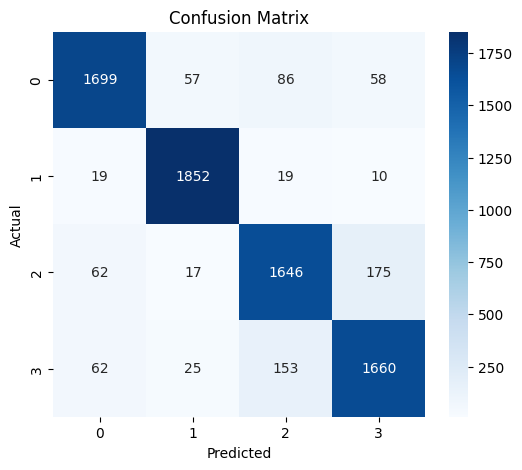

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_log_bow.png')
plt.show()

##### FLOPs: 

The Formulas related to Logistic Regression
- $x = (W^T)X + b$
- $\hat{y} = \sigma(z) = \sigma(w^{\top}x + b) = \frac{1}{1 + e^{-z}}$
- The FLOPs are $2d - 1 \approx 2d$

  Where d is the input dimension of the vector.

In [32]:
vec = log_model.named_steps['vectorizer']
d = len(vec.get_feature_names_out())
print("Number of features (d):",d)

Number of features (d): 5000


In [33]:
vec.get_feature_names_out()[:10]

array(['00', '000', '04', '05', '10', '100', '101', '10th', '11', '11th'],
      dtype=object)

In [34]:
results = {}
results[('BOW','Logistic Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                            'training_time': cpu_time},
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':inference_time,
                                            "flops/sample": 2*d}}

In [35]:
print(results)

{('BOW', 'Logistic Model'): {'Train': {'accuracy': 0.92945, 'f1_score': 0.9293277220248225, 'report': '              precision    recall  f1-score   support\n\n           0       0.94      0.91      0.93     30000\n           1       0.96      0.99      0.98     30000\n           2       0.91      0.90      0.90     30000\n           3       0.90      0.92      0.91     30000\n\n    accuracy                           0.93    120000\n   macro avg       0.93      0.93      0.93    120000\nweighted avg       0.93      0.93      0.93    120000\n', 'training_time': 4.46875}, 'Test': {'accuracy': 0.9022368421052631, 'f1_score': 0.9020746220159902, 'report': '              precision    recall  f1-score   support\n\n           0       0.92      0.89      0.91      1900\n           1       0.95      0.97      0.96      1900\n           2       0.86      0.87      0.87      1900\n           3       0.87      0.87      0.87      1900\n\n    accuracy                           0.90      7600\n   ma

### 2. Random Forest Classifier.

In [36]:
%%time

start=time.time()
start_cpu = time.process_time()
vectorizer = CountVectorizer(
    max_features=5000,
    stop_words = "english",
    ngram_range = (1,1)
)

rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    random_state=42,
    n_jobs = -1)

pipeline = Pipeline(
    [
        ('vectorizer',vectorizer),
        ('classifier', rf_model)
    ]
)

rf_model = pipeline.fit(X_train,y_train)
end = time.time() 
end_cpu = time.process_time()
train_time = end-start
cpu_time = end_cpu - start_cpu
print(train_time)
print(cpu_time)


3.210252523422241
8.015625
CPU times: total: 8.02 s
Wall time: 3.21 s


In [37]:
%%time
y_pred_train = rf_model.predict(X_train)

CPU times: total: 3.5 s
Wall time: 2.6 s


In [38]:
%%time
start = time.time()
y_pred = rf_model.predict(X_test)
end = time.time()
inference_time_rf = end-start

CPU times: total: 203 ms
Wall time: 192 ms


In [39]:
print("Training Accuracy With Random Forest Model")
train_accuracy = accuracy_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
train_report = classification_report(y_train,y_pred_train)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy With Random Forest Model

 Training Accuracy 0.789375

 Training F1 Score 0.7882561877600687

 Training Classification Report               precision    recall  f1-score   support

           0       0.83      0.79      0.81     30000
           1       0.80      0.91      0.85     30000
           2       0.83      0.69      0.75     30000
           3       0.71      0.78      0.74     30000

    accuracy                           0.79    120000
   macro avg       0.79      0.79      0.79    120000
weighted avg       0.79      0.79      0.79    120000



In [40]:
print("Test Accuracy with Random Forest Model")
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy with Random Forest Model

 Test Accuracy 0.781578947368421

 Test F1 Score 0.7799802304378137

 Test Classification Report               precision    recall  f1-score   support

           0       0.82      0.78      0.80      1900
           1       0.79      0.91      0.84      1900
           2       0.82      0.67      0.74      1900
           3       0.71      0.77      0.74      1900

    accuracy                           0.78      7600
   macro avg       0.79      0.78      0.78      7600
weighted avg       0.79      0.78      0.78      7600



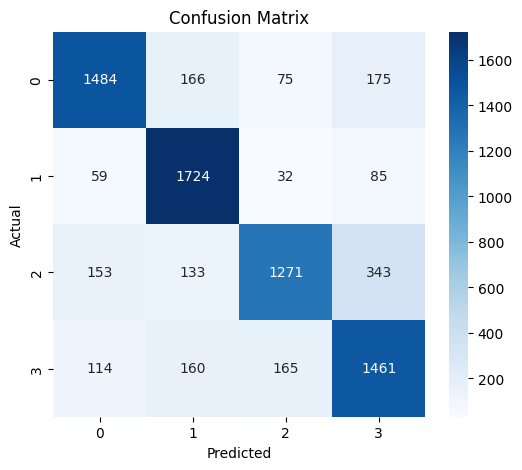

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_rf_bow.png')
plt.show()

#### FLOPs:
- Each tree in Random Forest has a depth, and this depth may vary based, The each step down the tree towards leave can be counted as a FLOP, so at maximum the maximum FLOPs from each tree is its depth. so to get FLOPs for the whole Random Forest model we can directly use the average of depths of all tree.

In [42]:
rf = rf_model.named_steps['classifier']
tree_depths = np.array([estimator.tree_.max_depth for estimator in rf.estimators_])
avg_max_depth = tree_depths.mean()
avg_flops_rf = rf.n_estimators * avg_max_depth
print("Average flops:",avg_flops_rf)

Average flops: 1000.0


In [43]:
results[('BOW','Random Forest Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                            'training_time':cpu_time
                                            },
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':inference_time_rf,
                                            'flops/sample':avg_flops_rf
                                             
                                            }}

### 3. XGBoost Classifier.

In [44]:
%%time

start_cpu = time.process_time()
start=time.time()
vectorizer = CountVectorizer(
    max_features=5000,
    stop_words = "english",
    ngram_range = (1,1)
)

xgb_model = XGBClassifier(
    n_estimators = 100,
    max_depth = 10,
    random_state=42,
    n_jobs = -1)

pipeline = Pipeline(
    [
        ('vectorizer',vectorizer),
        ('classifier', xgb_model)
    ]
)

xgb_model = pipeline.fit(X_train,y_train)
end = time.time() 
cpu_end = time.process_time()
train_time = end-start
cpu_time = cpu_end - start_cpu
print(train_time)
print(cpu_time)

6.9350011348724365
64.4375
CPU times: total: 1min 4s
Wall time: 6.94 s


The Cell time is 27.3 seconds, and the CPU Time is 5min 20s, the difference is because the model is trained parallely on 10 CPU Cores ,because my pc has 10 cores ,this will vary for each pc based on cores and other task running on the pc.  

In [45]:
%%time
y_pred_train = xgb_model.predict(X_train)

CPU times: total: 7.05 s
Wall time: 2.88 s


In [46]:
%%time
start = time.time()
y_pred = xgb_model.predict(X_test)
end = time.time()
inference_time_xgb = end-start

CPU times: total: 1.58 s
Wall time: 212 ms


In [47]:
print("Training Accuracy With XG Boost Model")
train_accuracy = accuracy_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
train_report = classification_report(y_train,y_pred_train)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy With XG Boost Model

 Training Accuracy 0.930625

 Training F1 Score 0.9305035109631844

 Training Classification Report               precision    recall  f1-score   support

           0       0.94      0.92      0.93     30000
           1       0.95      0.98      0.96     30000
           2       0.92      0.91      0.92     30000
           3       0.91      0.92      0.91     30000

    accuracy                           0.93    120000
   macro avg       0.93      0.93      0.93    120000
weighted avg       0.93      0.93      0.93    120000



In [48]:
print("Test Accuracy with XG Boost Model")
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy with XG Boost Model

 Test Accuracy 0.9046052631578947

 Test F1 Score 0.9043924797698842

 Test Classification Report               precision    recall  f1-score   support

           0       0.93      0.90      0.91      1900
           1       0.93      0.97      0.95      1900
           2       0.88      0.87      0.88      1900
           3       0.88      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



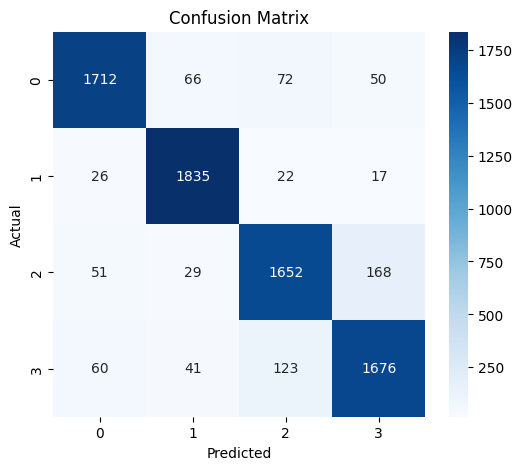

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_xgb_bow.png')
plt.show()

In [50]:
xgb_classifier = xgb_model.named_steps['classifier']
booster = xgb_classifier.get_booster()
total_trees = len(booster.get_dump())
flops_per_sample_xgb = total_trees * xgb_classifier.get_params()['max_depth']
print(f"Approx FLOPs per sample: {flops_per_sample_xgb}")

Approx FLOPs per sample: 4000


In [51]:
results[('BOW','XG Boost Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                             'training_time': cpu_time
                                            },
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':inference_time_xgb,
                                            'flops/sample':flops_per_sample_xgb}}

### 4. MLP Model. 

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.neural_network import MLPClassifier
from tensorflow.keras import regularizers
import tensorflow as tf

In [53]:
%%time

vectorizer = CountVectorizer(max_features=5000,
    stop_words = "english",
    ngram_range = (1,1)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec = X_train_vec.toarray()
X_test_vec = X_test_vec.toarray()

num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

input_dim = X_train_vec.shape[1]

mlp_model = Sequential([
    Dense(256, activation='relu',input_dim=input_dim, kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(128,activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(4,activation='softmax')
])

print("Model Summary:",mlp_model.summary())
mlp_model.compile(
    loss= 'categorical_crossentropy',
    optimizer = 'adam',
    metrics=['accuracy']
)



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               1280256   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 4)                 516       
                                                                 
Total params: 1,313,668
Trainable params: 1,313,668
Non-trainable params: 0
_________________________________________________________________
Model Summary: None
CPU times: total: 5.91 s
W

In [54]:
%%time

start_cpu = time.process_time()
start=time.time()
history = mlp_model.fit(
        X_train_vec, y_train_cat,
        epochs=10,
        batch_size=128,
        verbose=1
    )

end = time.time() 
cpu_end = time.process_time()
train_time = end-start
cpu_time = cpu_end - start_cpu
print(train_time)
print(cpu_time)

Epoch 1/10
938/938 [==============================] - 7s 3ms/step - loss: 0.5574 - accuracy: 0.8843 
Epoch 2/10
938/938 [==============================] - 3s 3ms/step - loss: 0.4483 - accuracy: 0.9010
Epoch 3/10
938/938 [==============================] - 3s 3ms/step - loss: 0.4274 - accuracy: 0.9049
Epoch 4/10
938/938 [==============================] - 3s 3ms/step - loss: 0.4090 - accuracy: 0.9086
Epoch 5/10
938/938 [==============================] - 3s 3ms/step - loss: 0.3932 - accuracy: 0.9125
Epoch 6/10
938/938 [==============================] - 3s 3ms/step - loss: 0.3822 - accuracy: 0.9159
Epoch 7/10
938/938 [==============================] - 4s 4ms/step - loss: 0.3738 - accuracy: 0.9187
Epoch 8/10
938/938 [==============================] - 4s 5ms/step - loss: 0.3680 - accuracy: 0.9208
Epoch 9/10
938/938 [==============================] - 4s 5ms/step - loss: 0.3631 - accuracy: 0.9221
Epoch 10/10
938/938 [==============================] - 5s 5ms/step - loss: 0.3603 - accuracy: 0.923

In [55]:
with tf.device('/CPU:0'):
    y_pred_train_probs = mlp_model.predict(X_train_vec)
y_pred_train = np.argmax(y_pred_train_probs, axis=1)
y_true_train = np.argmax(y_train_cat,axis=1)

3750/3750 [==============================] - 19s 5ms/step


In [56]:
start = time.time()
with tf.device('/CPU:0'):
    y_pred_probs = mlp_model.predict(X_test_vec)
end = time.time()

inference_time_mlp = (end - start) 
print(f"Average Inference Time sample: {inference_time*1000:.4f} ms")

y_pred = np.argmax(y_pred_probs, axis=1)
y_true_test = np.argmax(y_test_cat, axis=1)

238/238 [==============================] - 1s 5ms/step
Average Inference Time sample: 162.6215 ms


In [57]:
print("Training Accuracy With MLP Model")
train_accuracy = accuracy_score(y_true_train, y_pred_train)
train_f1 = f1_score(y_true_train, y_pred_train, average='weighted', zero_division=0)
train_report = classification_report(y_true_train,y_pred_train)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy With MLP Model

 Training Accuracy 0.9500416666666667

 Training F1 Score 0.9500021568909637

 Training Classification Report               precision    recall  f1-score   support

           0       0.96      0.94      0.95     30000
           1       0.97      0.99      0.98     30000
           2       0.94      0.92      0.93     30000
           3       0.92      0.94      0.93     30000

    accuracy                           0.95    120000
   macro avg       0.95      0.95      0.95    120000
weighted avg       0.95      0.95      0.95    120000



In [58]:
print("Test Accuracy with MLP Model")
test_accuracy = accuracy_score(y_true_test, y_pred)
test_f1 = f1_score(y_true_test, y_pred, average='weighted', zero_division=0)
test_report = classification_report(y_true_test,y_pred)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy with MLP Model

 Test Accuracy 0.9085526315789474

 Test F1 Score 0.908455211305609

 Test Classification Report               precision    recall  f1-score   support

           0       0.94      0.91      0.92      1900
           1       0.94      0.97      0.96      1900
           2       0.88      0.87      0.88      1900
           3       0.88      0.88      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



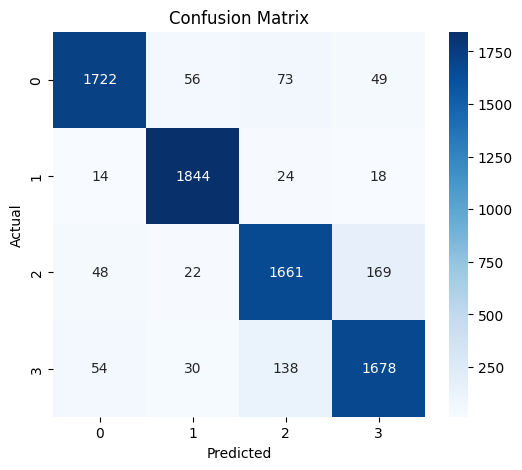

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_mlp_bow.png')
plt.show()

In [60]:
def analytical_flops(model):
    flops = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dense):
            in_features = layer.input_shape[-1]
            out_features = layer.output_shape[-1]
            flops += 2 * in_features * out_features
    return flops

flops = analytical_flops(mlp_model)
print(f"Analytical FLOPs: {flops} FLOPs")


Analytical FLOPs: 2626560 FLOPs


In [61]:
results[('BOW', 'MLP Model')] = {
    'Train':
            {'accuracy': train_accuracy,
            'f1_score': train_f1,
            'report': train_report,
             'training_time': cpu_time
            },
    'Test':
            {'accuracy': test_accuracy,
            'f1_score': test_f1,
            'report': test_report,
            'inference_time':inference_time_mlp,
            'flops/sample':flops}}

### MLP Model - Scratch Code.

In [62]:
import numpy as np

In [63]:
num_features = X_train_vec.shape[1]
num_classes = len(np.unique(y_train))

def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

y_train_oh = one_hot_encode(y_train, num_classes)
y_test_oh = one_hot_encode(y_test, num_classes)

In [64]:
y_train_oh

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

In [65]:
y_train

0         2
1         2
2         2
3         2
4         2
         ..
119995    0
119996    1
119997    1
119998    1
119999    1
Name: label, Length: 120000, dtype: int64

In [66]:
num_features

5000

In [67]:
def init_params(input_dim, hidden1, hidden2, output_dim):
    params = {
        'W1' : np.random.randn(input_dim,hidden1) * np.sqrt(2./input_dim),
        'b1' : np.zeros((1,hidden1)),
        'W2' : np.random.randn(hidden1, hidden2) * np.sqrt(2./hidden1),
        'b2' : np.zeros((1,hidden2)),
        'W3' : np.random.randn(hidden2, output_dim) * np.sqrt(2./hidden2),
        'b3' : np.zeros((1,output_dim))
    }
    return params

params = init_params(num_features, 256, 128, num_classes)

In [68]:
def relu(Z):
    return np.maximum(0,Z)
def relu_deriv(Z):
    return (Z>0).astype(float)  
def softmax(Z):
    expZ = np.exp(Z-np.max(Z,axis=1, keepdims=True)) # we are essentially normalizing before hand  by value - max_value.
    return expZ / np.sum(expZ, axis=1, keepdims=True)

In [69]:
def forward(X, params):
    Z1 = X @ params['W1'] + params['b1']
    A1 = relu(Z1)
    Z2 = A1 @ params['W2'] + params['b2']
    A2 = relu(Z2)
    Z3 = A2 @ params['W3'] + params['b3']
    A3 = softmax(Z3)

    cache = (X, Z1, A1, Z2, A2, Z3, A3)
    return A3, cache

def backward(params, cache, y_true):
    X, Z1, A1,Z2,A2, Z3, A3 = cache 
    m = X.shape[0]

    dZ3 = A3 - y_true
    dW3 = (A2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    dA2 = dZ3 @ params['W3'].T
    dZ2 = dA2 * relu_deriv(Z2)
    dW2 = (A1.T @ dZ2) /m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ params['W2'].T
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1 , axis=0, keepdims=True) /m

    grads = {
        'dW1': dW1, 'db1': db1,
        'dW2': dW2, 'db2': db2,
        'dW3': dW3, 'db3': db3
    }

    return grads

In [70]:
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-9)) / m
    return loss


In [71]:
def update_params(params, grads,lr):
    for key in params.keys():
        params[key] -= lr*grads['d' + key]

    return params

In [72]:
def train(X, y, params, epochs=10, lr=0.01, batch_size=128):
    m = X.shape[0]
    for epoch in range(epochs):
        perm = np.random.permutation(m)
        X_shuffled, y_shuffled = X[perm], y[perm]
        
        losses = []
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            y_pred, cache = forward(X_batch, params)
            loss = compute_loss(y_batch, y_pred)
            grads = backward(params, cache, y_batch)
            params = update_params(params, grads, lr)
            losses.append(loss)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss = {np.mean(losses):.4f}")
    return params


In [73]:
%%time 
start = time.time()
cpu_start = time.process_time()

def predict(X, params):
    y_pred, _ = forward(X, params)
    return np.argmax(y_pred, axis=1)

# train
trained_params = train(X_train_vec, y_train_oh, params, epochs=10, lr=0.01)

end = time.time()
cpu_end = time.process_time()
cpu_time = cpu_end - cpu_start
cell_time = end-start
print(cpu_time)

Epoch 1/10, Loss = 1.1784
Epoch 2/10, Loss = 0.5863
Epoch 3/10, Loss = 0.4000
Epoch 4/10, Loss = 0.3455
Epoch 5/10, Loss = 0.3168
Epoch 6/10, Loss = 0.2975
Epoch 7/10, Loss = 0.2828
Epoch 8/10, Loss = 0.2709
Epoch 9/10, Loss = 0.2609
Epoch 10/10, Loss = 0.2522
2095.1875
CPU times: total: 34min 55s
Wall time: 13min 24s


In [74]:
%%time
start_inf_time = time.process_time()
y_pred = predict(X_test_vec, trained_params)
end_inf_time = time.process_time()
inf_time_smlp = end_inf_time - start_inf_time

CPU times: total: 8 s
Wall time: 3.07 s


In [75]:
y_pred_train = predict(X_train_vec, trained_params)

In [76]:
np.array(y_pred)

array([2, 3, 3, ..., 1, 2, 3], dtype=int64)

In [77]:
y_test

0       2
1       3
2       3
3       3
4       3
       ..
7595    0
7596    1
7597    1
7598    2
7599    2
Name: label, Length: 7600, dtype: int64

In [78]:
print("Training Accuracy With Scratch MLP Model")
train_accuracy = accuracy_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
train_report = classification_report(y_train,y_pred_train)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy With Scratch MLP Model

 Training Accuracy 0.9203

 Training F1 Score 0.920179347279173

 Training Classification Report               precision    recall  f1-score   support

           0       0.94      0.90      0.92     30000
           1       0.96      0.98      0.97     30000
           2       0.89      0.90      0.89     30000
           3       0.89      0.90      0.90     30000

    accuracy                           0.92    120000
   macro avg       0.92      0.92      0.92    120000
weighted avg       0.92      0.92      0.92    120000



In [79]:
print("Test Accuracy with Scratch MLP Model")
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy with Scratch MLP Model

 Test Accuracy 0.9023684210526316

 Test F1 Score 0.9021901376162059

 Test Classification Report               precision    recall  f1-score   support

           0       0.92      0.89      0.91      1900
           1       0.95      0.97      0.96      1900
           2       0.86      0.87      0.87      1900
           3       0.88      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



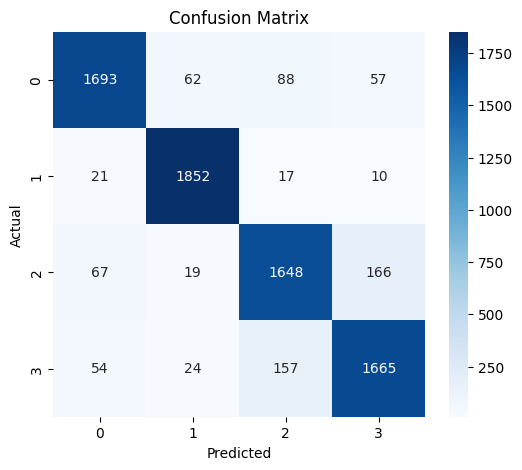

In [80]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_mlp_scratch_bow.png')
plt.show()

For a fully connected (dense) layer, each output neuron performs:

FLOPs per layer  = 2 * (input size) * (output size)

- Layer 1
    FLOPs 1
    =2×N×d×h

- Layer 2
    FLOPs
    2 =2×N×h

- Output layer
    FLOPs 3
    =2×N×h

###### Note we will be calculating only the forward pass FLOPs
  

In [81]:
def mlp_flops(d, h1, h2, c, N=1):
    forward = 2 * N * (d*h1 + h1*h2 + h2*c)
    return forward

flops  = mlp_flops(num_features, 256,128,4,128)
print("FLOPs per sample of forward pass", flops / 128.0)


FLOPs per sample of forward pass 2626560.0


In [82]:
results[('BOW', 'Scratch MLP Model')] = {
    'Train':
            {'accuracy': train_accuracy,
            'f1_score': train_f1,
            'report': train_report,
             'training_time': cpu_time
            },
    'Test':
            {'accuracy': test_accuracy,
            'f1_score': test_f1,
            'report': test_report,
            'inference_time':inf_time_smlp,
            'flops/sample':flops/128.0}}

In [83]:
import pandas as pd

# flatten nested dict into a list of rows
rows = []

for (vectorizer, model), metrics in results.items():
    row = {
        "Vectorizer": vectorizer,
        "Model": model,
        "Train_Accuracy": metrics["Train"]["accuracy"],
        "Train_F1": metrics["Train"]["f1_score"],
        "Test_Accuracy": metrics["Test"]["accuracy"],
        "Test_F1": metrics["Test"]["f1_score"],
        "Inference_Time": metrics["Test"].get("inference_time", None),
        "FLOPs_per_Sample": metrics["Test"].get("flops/sample", None),
        "Training_Time": metrics['Train'].get('training_time',None)
    }
    rows.append(row)

# create DataFrame
df_results = pd.DataFrame(rows)

# optional: set a clean display order
df_results = df_results[
    ["Vectorizer", "Model", "Train_Accuracy", "Train_F1",
     "Test_Accuracy", "Test_F1", "Inference_Time", "FLOPs_per_Sample","Training_Time"]
]

print(df_results)

  Vectorizer                Model  Train_Accuracy  Train_F1  Test_Accuracy  \
0        BOW       Logistic Model        0.929450  0.929328       0.902237   
1        BOW  Random Forest Model        0.789375  0.788256       0.781579   
2        BOW       XG Boost Model        0.930625  0.930504       0.904605   
3        BOW            MLP Model        0.950042  0.950002       0.908553   
4        BOW    Scratch MLP Model        0.920300  0.920179       0.902368   

    Test_F1  Inference_Time  FLOPs_per_Sample  Training_Time  
0  0.902075        0.162621           10000.0       4.468750  
1  0.779980        0.191875            1000.0       8.015625  
2  0.904392        0.212104            4000.0      64.437500  
3  0.908455        1.316121         2626560.0      70.421875  
4  0.902190        8.000000         2626560.0    2095.187500  


In [84]:
df_results

,Vectorizer,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1,Inference_Time,FLOPs_per_Sample,Training_Time
0,BOW,Logistic Model,0.929450,0.929328,0.902237,0.902075,0.162621,10000.0,4.468750
1,BOW,Random Forest Model,0.789375,0.788256,0.781579,0.779980,0.191875,1000.0,8.015625
2,BOW,XG Boost Model,0.930625,0.930504,0.904605,0.904392,0.212104,4000.0,64.437500
3,BOW,MLP Model,0.950042,0.950002,0.908553,0.908455,1.316121,2626560.0,70.421875
4,BOW,Scratch MLP Model,0.920300,0.920179,0.902368,0.902190,8.000000,2626560.0,2095.187500


In [60]:
df_results.to_csv('datasets/results_bow.csv')